# Training on INCLUDE_50 Dataset

## Preprocessing Data

In [2]:
import pandas as pd
import numpy as np
import os

import tensorflow as tf
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Flatten

from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm

In [3]:
# Checking whether the gpu is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        print("Using GPU:", gpus)

    except RuntimeError as e:
        print(e)

else:
    print("No GPU found.")

Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
train_data = pd.read_csv('Dataset/train.csv')
test_data = pd.read_csv('Dataset/test.csv')

train_data.sample(5)

,parent_label,label,video_path,include_50
1395,Society,11. War,Society/11. War/MVI_8699.MP4,False
1837,Home,49. Ring,Home/49. Ring/MVI_4953.mp4,False
1904,Home,48. Card,Home/48. Card/MVI_9084.MP4,False
1370,People,71. Husband,People/71. Husband/MVI_5113.mp4,False
3534,Adjectives,2. quiet,Adjectives/2. quiet/MVI_9451.mp4,True


In [5]:
# Extracting labels and video paths for the videos that are from the include 50 dataset

labels = []
train_path_I50 = []

for i in range(len(train_data)):
    if train_data['include_50'][i] == True:
        labels.append(train_data['label'][i])
        train_path_I50.append("Dataset\\" + train_data['video_path'][i])

labels = pd.Series(labels).unique()
labels = pd.Series(labels).to_list()

train_path_I50 = pd.Series(train_path_I50)

# train_path_I50.sample(5), labels.sample(5)
labels[:5]

['1. loud', '19. House', '83. big large', '91. Priest', '23. Court']

In [6]:
# Prining the graph for labels and the number of videos for each label in include 50 dataset


In [7]:
label_map = dict()

# Creating a dictionary of labels with their corresponding index 
for i in range(len(labels)):
    # Splitting Label from num
    split = labels[i].split(" ")
    
    # Joining the ramining str to make a full label name
    label = split[1:]
    label = " ".join(label)
        
    label_map[i] = label

labels = list(label_map.values())
  
label_map    

{0: 'loud',
 1: 'House',
 2: 'big large',
 3: 'Priest',
 4: 'Court',
 5: 'train ticket',
 6: 'it',
 7: 'Shoes',
 8: 'Dog',
 9: 'Bank',
 10: 'Thank you',
 11: 'Election',
 12: 'Cow',
 13: 'Window',
 14: 'quiet',
 15: 'dry',
 16: 'long',
 17: 'Hello',
 18: 'Bird',
 19: 'Hat',
 20: 'Black',
 21: 'short',
 22: 'White',
 23: 'Fan',
 24: 'new',
 25: 'Store or Shop',
 26: 'Monday',
 27: 'Death',
 28: 'Cell phone',
 29: 'you (plural)',
 30: 'T-Shirt',
 31: 'Girl',
 32: 'Father',
 33: 'Red',
 34: 'hot',
 35: 'Fall',
 36: 'I',
 37: 'Time',
 38: 'Car',
 39: 'Good Morning',
 40: 'Summer',
 41: 'Paint',
 42: 'Teacher',
 43: 'Brother',
 44: 'good',
 45: 'happy',
 46: 'Boy',
 47: 'small little',
 48: 'Pen',
 49: 'Year'}

In [8]:
# Loading all the labeled videos in the dataset
X = []
y= []

for label in tqdm(labels):
    label_videos = os.listdir("MP_data/"+label)
    
    
    for video in label_videos:        
        res = np.load("MP_data/" + f"{label}/" + video,allow_pickle=True)
        X.append(res)
        y.append(labels.index(label))        

len(X),len(y)

        

  0%|          | 0/50 [00:00<?, ?it/s]

(675, 675)

In [9]:
# Bhai yha meine kya hi harkat kari thi gandi wali bhai agar meine har vedio ka input ek baar mein hi pahucha dunga toh kaise kaam banega sab vedio ke inputs ko alag lena hoga na bhai :))))))

# Padding the videos to make them of the same length

max_frames = max([len(video) for video in X])
max_frames

X = pad_sequences(X, maxlen=max_frames, padding='post', dtype='float32')

print(X.shape)


(675, 154, 1662)


In [10]:
X= np.array(X)
y= np.array(y)
y = to_categorical(y)

X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                #   test_size=0.2, 
                                                  test_size=0.1, 
                                                  random_state=42,
                                                  shuffle=True) 

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (607, 154, 1662)
X_val shape: (68, 154, 1662)
y_train shape: (607, 50)
y_val shape: (68, 50)


# Model

## Architecture

In [11]:
import keras

# input_shape = (154, 1662)
input_shape = X_train[0].shape #(154, 1662)
num_classes =  len(label_map.keys())#50


gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

In [ ]:
INCLUDESEQ50_V2 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(128, activation='relu'),
        
        # Output layer
        Dense(num_classes, activation='softmax')
])

model = INCLUDESEQ50_V2

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build(input_shape=(input_shape))

model.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_31 (Bidirecti  (None, 154, 128)         884224    
 onal)                                                           
                                                                 
 bidirectional_32 (Bidirecti  (None, 154, 128)         98816     
 onal)                                                           
                                                                 
 bidirectional_33 (Bidirecti  (None, 154, 128)         98816     
 onal)                                                           
                                                                 
 bidirectional_34 (Bidirecti  (None, 154, 128)         98816     
 onal)                                                           
                                                                 
 flatten_11 (Flatten)        (None, 19712)           

In [ ]:
INCLUDE8_V3 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        # Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V3


# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])                       
model.compile(optimizer='adam', loss='kullback_leibler_divergence', metrics=['accuracy'])                       
 
model.build()
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_3 (Bidirectio  (None, 154, 128)         884224    
 nal)                                                            
                                                                 
 bidirectional_4 (Bidirectio  (None, 154, 256)         263168    
 nal)                                                            
                                                                 
 bidirectional_5 (Bidirectio  (None, 154, 128)         164352    
 nal)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 19712)             0         
                                                                 
 dense_2 (Dense)             (None, 64)                1261632   
                                                      

In [17]:
#Experimenting with different dropout configurations
# Try here both dropout and early stopping

from tensorflow.keras.layers import Dropout
# from tensorflow.keras import regularizers


INCLUDE8_V4 = keras.Sequential([        
        Input(shape=input_shape),        

        # Bidirectional LSTM layers
        
        Dropout(0.1),
        Bidirectional(LSTM(32, return_sequences=True)),
        Dropout(0.2),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.1),
        Bidirectional(LSTM(32, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        Dropout(0.5),
        # Fully connected layer
        Dense(64, activation='relu'),
        # Dense(64, activation='relu',kernel_regularizer=regularizers.l2(0.001)),
        # Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V4

# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.compile(optimizer='adam', loss='kullback_leibler_divergence', metrics=['accuracy'])          
 
model.build()
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_5 (Dropout)         (None, 154, 1662)         0         
                                                                 
 bidirectional_6 (Bidirectio  (None, 154, 64)          433920    
 nal)                                                            
                                                                 
 dropout_6 (Dropout)         (None, 154, 64)           0         
                                                                 
 bidirectional_7 (Bidirectio  (None, 154, 128)         66048     
 nal)                                                            
                                                                 
 dropout_7 (Dropout)         (None, 154, 128)          0         
                                                                 
 bidirectional_8 (Bidirectio  (None, 154, 64)         

In [ ]:
INCLUDESEQ50_V5 = keras.Sequential([        
        Bidirectional(LSTM(128, return_sequences=True, activation='relu'), input_shape=(input_shape)),
        LSTM(64, return_sequences=True, activation='relu', input_shape=(input_shape)),
        LSTM(128, return_sequences=True, activation='relu'),
        LSTM(64, return_sequences=False, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDESEQ50_V5

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build(input_shape=(input_shape))

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 154, 64)           442112    
                                                                 
 lstm_5 (LSTM)               (None, 154, 128)          98816     
                                                                 
 lstm_6 (LSTM)               (None, 64)                49408     
                                                                 
 dense_3 (Dense)             (None, 64)                4160      
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 50)                1650      
                                                                 
Total params: 598,226
Trainable params: 598,226
Non-tr

In [18]:
# Implemented ealy stopping to prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train,
          y_train,
          validation_data=(X_val, y_val), 
          epochs=40)
        #   batch_size= 4,
        #   callbacks=[early_stop])


Epoch 1/40
19/19 [==============================] - 9s 170ms/step - loss: 3.9338 - accuracy: 0.0280 - val_loss: 3.9171 - val_accuracy: 0.0147
Epoch 2/40
19/19 [==============================] - 1s 79ms/step - loss: 3.8740 - accuracy: 0.0264 - val_loss: 3.9448 - val_accuracy: 0.0000e+00
Epoch 3/40
19/19 [==============================] - 1s 77ms/step - loss: 3.8210 - accuracy: 0.0395 - val_loss: 3.8345 - val_accuracy: 0.0294
Epoch 4/40
19/19 [==============================] - 1s 79ms/step - loss: 3.7798 - accuracy: 0.0445 - val_loss: 3.8179 - val_accuracy: 0.0147
Epoch 5/40
19/19 [==============================] - 1s 77ms/step - loss: 3.7271 - accuracy: 0.0428 - val_loss: 3.8460 - val_accuracy: 0.0294
Epoch 6/40
19/19 [==============================] - 1s 78ms/step - loss: 3.6809 - accuracy: 0.0610 - val_loss: 3.7495 - val_accuracy: 0.0147
Epoch 7/40
19/19 [==============================] - 2s 80ms/step - loss: 3.6483 - accuracy: 0.0527 - val_loss: 3.7992 - val_accuracy: 0.0294
Epoch 8/

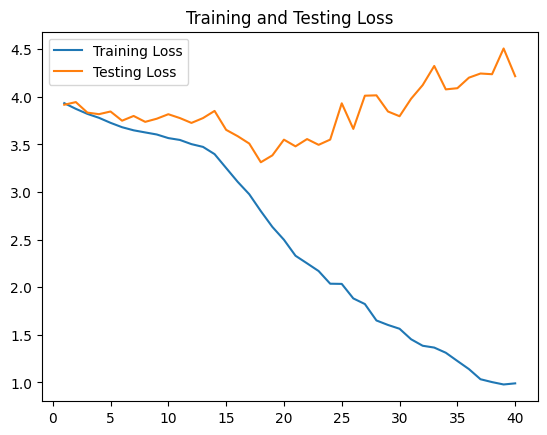

<Figure size 640x480 with 0 Axes>

In [19]:
# Plotting training and validation loss
from matplotlib import pyplot as plt

train_loss = history.history['loss']
eval_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.plot(epochs,train_loss,label = "Training Loss")
plt.plot(epochs,eval_loss,label = "Testing Loss")

plt.title("Training and Testing Loss")
plt.legend()
plt.figure()
plt.show();

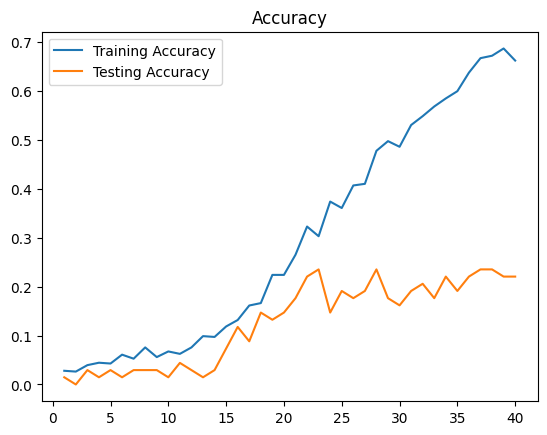

<Figure size 640x480 with 0 Axes>

In [20]:
train_acc = history.history['accuracy']
eval_acc = history.history['val_accuracy']
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs,train_acc,label = "Training Accuracy")
plt.plot(epochs,eval_acc,label = "Testing Accuracy")

plt.title("Accuracy")
plt.legend()
plt.figure()
plt.show();

In [ ]:
# Predict probabilities for the test data
# probabilities = model.predict(X_val)
arr = np.load("MP_data\Bank\MVI_3336.npy")
print(arr.shape)
probabilities = model.predict(arr)

# Convert probabilities to class labels
predicted_classes = np.argmax(probabilities, axis=-1)

for i in range(10):
    print(f'Predicted: {label_map[predicted_classes[i]]}, True: {label_map[np.argmax(y_val[i])]}')


(63, 1662)


InvalidArgumentError: Graph execution error:

transpose expects a vector of size 2. But input(1) is a vector of size 3
	 [[{{node transpose}}]]
	 [[sequential_7/bidirectional_21/backward_lstm_21/PartitionedCall]] [Op:__inference_predict_function_184916]

In [ ]:
# model.save('INCLUDE_8_V1.h5')
try:
    os.mkdir("Model")
except:
    pass

keras.saving.save_model(model, "Model\INCLUDE_8_V3.keras")